In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

from datasets import load_dataset
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

csv_file_path = '/content/drive/MyDrive/2025-26/NLP/dancing1000v2.csv'
songs_dataset = load_dataset('csv', data_files=csv_file_path)

dataset = songs_dataset['train']
dataset = dataset.filter(lambda x: x['lyrics'] is not None and x['danceability'] is not None)

def create_danceability_labels(example):
    danceability = example['danceability']
    if danceability < 0.4:
        example['labels'] = 0
    elif danceability > 0.6:
        example['labels'] = 1
    else:
        example['labels'] = -1
    return example

dataset = dataset.map(create_danceability_labels)
dataset = dataset.filter(lambda x: x['labels'] != -1)

dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset['train']
test_dataset = dataset['test']

X_train_text = train_dataset['lyrics']
y_train = np.array(train_dataset['labels'])
X_test_text = test_dataset['lyrics']
y_test = np.array(test_dataset['labels'])

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    print(f"Evaluating {name}")
    model.fit(X_train, y_train)
    predicted_labels = model.predict(X_test)
    accuracy = accuracy_score(y_test, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predicted_labels, average="binary", zero_division=0)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 2),
        "Precision": round(precision, 2),
        "Recall": round(recall, 2),
        "F1 Score": round(f1, 2)
    })
    print(classification_report(y_test, predicted_labels, target_names=["low danceability", "high danceability"], zero_division=0))
    print("\n")

results_df = pd.DataFrame(results)
print("Baseline Metrics")
print(results_df.to_string(index=False))

Evaluating Logistic Regression
                   precision    recall  f1-score   support

 low danceability       0.73      0.87      0.79       104
high danceability       0.82      0.65      0.72        96

         accuracy                           0.76       200
        macro avg       0.77      0.76      0.76       200
     weighted avg       0.77      0.76      0.76       200



Evaluating K-Nearest Neighbors
                   precision    recall  f1-score   support

 low danceability       0.65      0.65      0.65       104
high danceability       0.62      0.61      0.62        96

         accuracy                           0.64       200
        macro avg       0.63      0.63      0.63       200
     weighted avg       0.63      0.64      0.63       200



Evaluating Random Forest
                   precision    recall  f1-score   support

 low danceability       0.74      0.78      0.76       104
high danceability       0.74      0.70      0.72        96

         accurac

In [ ]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
true_danceability = np.array(test_dataset["danceability"])

additional_results = []

for name, model in models.items():
    print(f"Additional evaluation for {name}")

    model.fit(X_train, y_train)

    predicted_labels = model.predict(X_test)

    high_class_probs = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, predicted_labels, average="binary", zero_division=0
    )

    mae = mean_absolute_error(true_danceability, high_class_probs)
    mse = mean_squared_error(true_danceability, high_class_probs)
    rmse = np.sqrt(mse)
    spearman_corr, spearman_p = spearmanr(true_danceability, high_class_probs)

    additional_results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "Spearman Correlation": round(spearman_corr, 4),
        "Spearman p-value": round(spearman_p, 5)
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Spearman Correlation: {spearman_corr:.4f}")
    print(f"Spearman p-value: {spearman_p:.5f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predicted_labels))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predicted_labels,
        target_names=["low danceability", "high danceability"],
        zero_division=0
    ))

    print("\n" + "="*60 + "\n")

additional_results_df = pd.DataFrame(additional_results)
print("Additional Evaluation Metrics")
print(additional_results_df.to_string(index=False))

Additional evaluation for Logistic Regression
Accuracy: 0.7600
Precision: 0.8158
Recall: 0.6458
F1 Score: 0.7209
MAE: 0.1416
MSE: 0.0293
RMSE: 0.1712
Spearman Correlation: 0.6276
Spearman p-value: 0.00000

Confusion Matrix:
[[90 14]
 [34 62]]

Classification Report:
                   precision    recall  f1-score   support

 low danceability       0.73      0.87      0.79       104
high danceability       0.82      0.65      0.72        96

         accuracy                           0.76       200
        macro avg       0.77      0.76      0.76       200
     weighted avg       0.77      0.76      0.76       200



Additional evaluation for K-Nearest Neighbors
Accuracy: 0.6350
Precision: 0.6211
Recall: 0.6146
F1 Score: 0.6178
MAE: 0.2255
MSE: 0.0767
RMSE: 0.2770
Spearman Correlation: 0.3384
Spearman p-value: 0.00000

Confusion Matrix:
[[68 36]
 [37 59]]

Classification Report:
                   precision    recall  f1-score   support

 low danceability       0.65      0.65      0.6

In [ ]:
import numpy as np
random_probs = np.full_like(true_danceability, 0.5)
random_predicted_labels = (random_probs > 0.5).astype(int)

random_accuracy = accuracy_score(y_test, random_predicted_labels)
random_precision, random_recall, random_f1, _ = precision_recall_fscore_support(y_test, random_predicted_labels, average="binary", zero_division=0)

random_mae = mean_absolute_error(true_danceability, random_probs)
random_mse = mean_squared_error(true_danceability, random_probs)
random_rmse = np.sqrt(random_mse)
random_spearman_corr, random_spearman_p = spearmanr(true_danceability, random_probs)

bert_accuracy = 0.8200
bert_precision = 0.8488
bert_recall = 0.7604
bert_f1 = 0.8022


bert_results_row = pd.DataFrame([{
    "Model": "BERT MODEL",
    "Accuracy": round(bert_accuracy, 2),
    "Precision": round(bert_precision, 2),
    "Recall": round(bert_recall, 2),
    "F1 Score": round(bert_f1, 2)
}])

random_results_row = pd.DataFrame([{
    "Model": "Random Baseline",
    "Accuracy": round(random_accuracy, 2),
    "Precision": round(random_precision, 2),
    "Recall": round(random_recall, 2),
    "F1 Score": round(random_f1, 2)
}])

global results_df
results_df = pd.concat([results_df, bert_results_row, random_results_row], ignore_index=True)


bert_additional_results_row = pd.DataFrame([{
    "Model": "BERT MODEL",
    "Accuracy": round(bert_accuracy, 4),
    "Precision": round(bert_precision, 4),
    "Recall": round(bert_recall, 4),
    "F1 Score": round(bert_f1, 4),
    "MAE": np.nan,
    "MSE": np.nan,
    "RMSE": np.nan,
    "Spearman Correlation": np.nan,
    "Spearman p-value": np.nan
}])

random_additional_results_row = pd.DataFrame([{
    "Model": "Random Baseline",
    "Accuracy": round(random_accuracy, 4),
    "Precision": round(random_precision, 4),
    "Recall": round(random_recall, 4),
    "F1 Score": round(random_f1, 4),
    "MAE": round(random_mae, 4),
    "MSE": round(random_mse, 4),
    "RMSE": round(random_rmse, 4),
    "Spearman Correlation": round(random_spearman_corr, 4),
    "Spearman p-value": round(random_spearman_p, 5)
}])

global additional_results_df
additional_results_df = pd.concat([additional_results_df, bert_additional_results_row, random_additional_results_row], ignore_index=True)

print("Updated results_df and additional_results_df with BERT Model and Random Baseline.")
display(results_df)
display(additional_results_df)

Updated results_df and additional_results_df with BERT Model and Random Baseline.


/tmp/ipykernel_3792/3556683468.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  random_spearman_corr, random_spearman_p = spearmanr(true_danceability, random_probs)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.76,0.82,0.65,0.72
1,K-Nearest Neighbors,0.64,0.62,0.61,0.62
2,Random Forest,0.74,0.74,0.70,0.72
3,BERT MODEL,0.82,0.85,0.76,0.80
4,Random Baseline,0.52,0.00,0.00,0.00
5,BERT MODEL,0.82,0.85,0.76,0.80
6,Random Baseline,0.52,0.00,0.00,0.00


,Model,Accuracy,Precision,Recall,F1 Score,MAE,MSE,RMSE,Spearman Correlation,Spearman p-value
0,Logistic Regression,0.760,0.8158,0.6458,0.7209,0.1416,0.0293,0.1712,0.6276,0.0
1,K-Nearest Neighbors,0.635,0.6211,0.6146,0.6178,0.2255,0.0767,0.2770,0.3384,0.0
2,Random Forest,0.740,0.7444,0.6979,0.7204,0.1381,0.0293,0.1712,0.6353,0.0
3,BERT MODEL,0.820,0.8488,0.7604,0.8022,NaN,NaN,NaN,NaN,NaN
4,Random Baseline,0.520,0.0000,0.0000,0.0000,0.2105,0.0501,0.2237,NaN,NaN
5,BERT MODEL,0.820,0.8488,0.7604,0.8022,NaN,NaN,NaN,NaN,NaN
6,Random Baseline,0.520,0.0000,0.0000,0.0000,0.2105,0.0501,0.2237,NaN,NaN


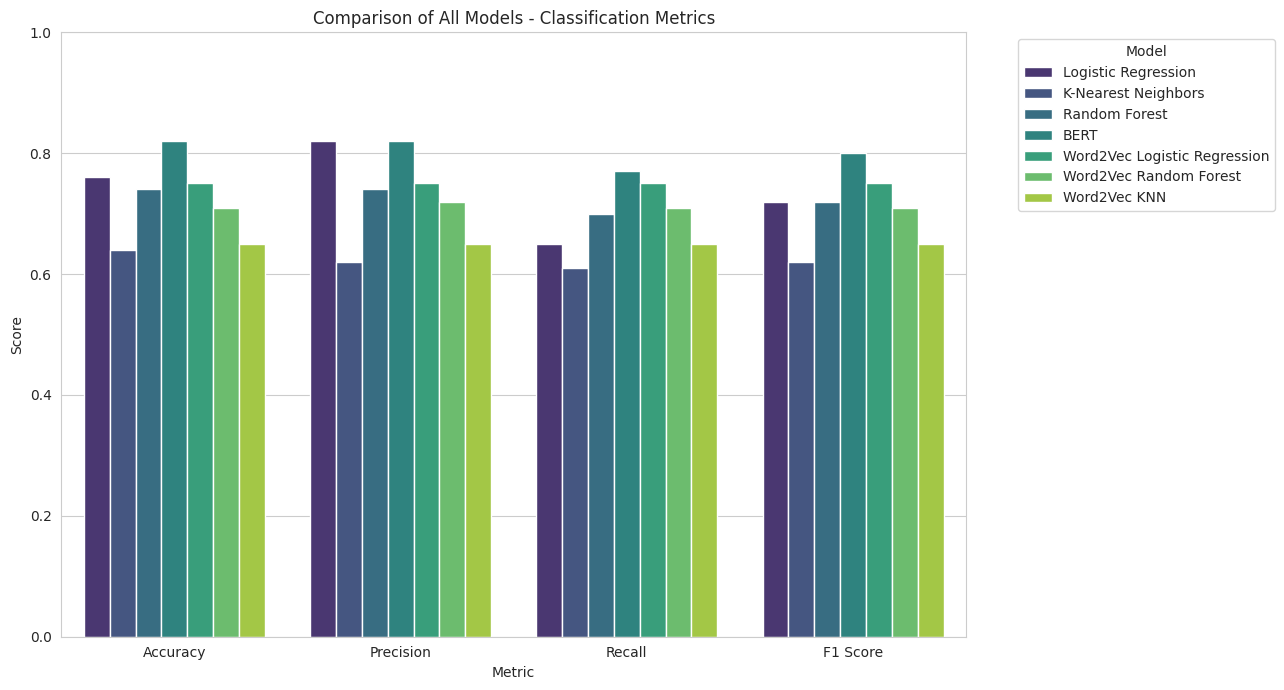

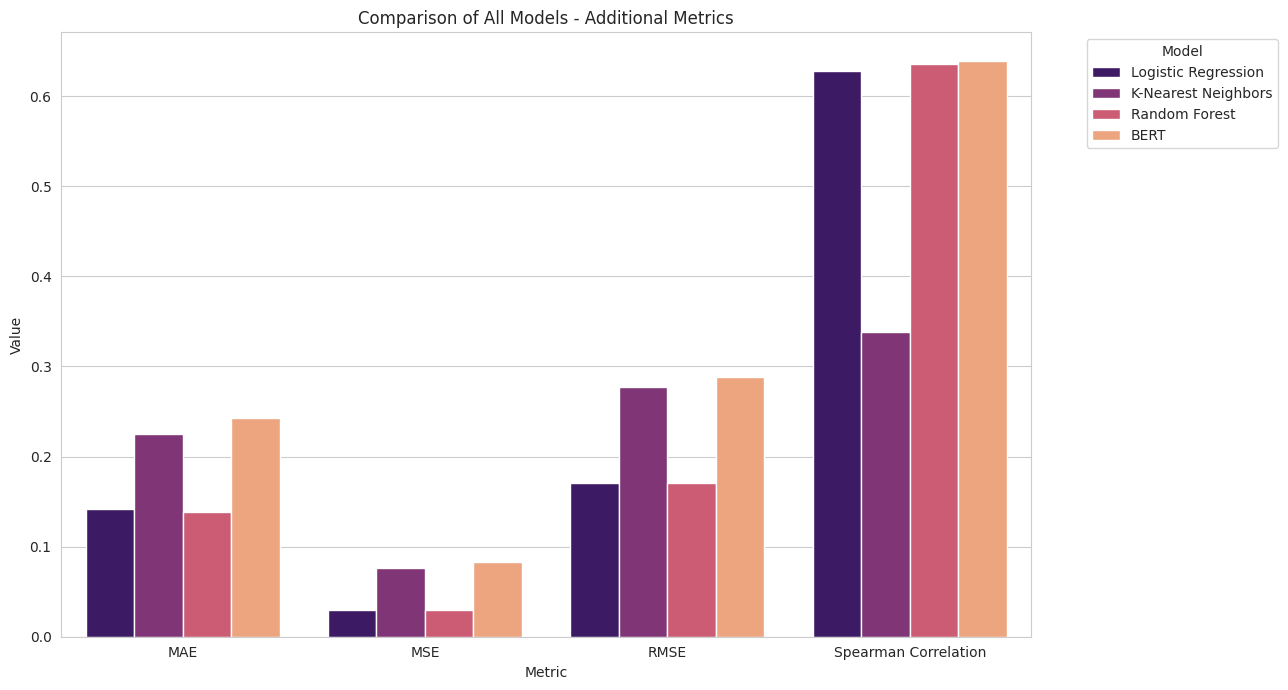

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

models_to_exclude_from_initial_df = [
    'Random Baseline',
    'BERT MODEL',
    'Word2Vec'
]

filtered_results_df = results_df[
    ~results_df['Model'].isin(models_to_exclude_from_initial_df)
].copy()

bert_results = pd.DataFrame([{
    'Model': 'BERT',
    'Accuracy': 0.82,
    'Precision': 0.82,
    'Recall': 0.77,
    'F1 Score': 0.80
}])

word2vec_results = pd.DataFrame([
    {
        'Model': 'Word2Vec Logistic Regression',
        'Accuracy': 0.75,
        'Precision': 0.75,
        'Recall': 0.75,
        'F1 Score': 0.75
    },
    {
        'Model': 'Word2Vec Random Forest',
        'Accuracy': 0.71,
        'Precision': 0.72,
        'Recall': 0.71,
        'F1 Score': 0.71
    },
    {
        'Model': 'Word2Vec KNN',
        'Accuracy': 0.65,
        'Precision': 0.65,
        'Recall': 0.65,
        'F1 Score': 0.65
    }
])

combined_results_df = pd.concat(
    [
        filtered_results_df,
        bert_results,
        word2vec_results
    ],
    ignore_index=True
)

metrics_df_melted = combined_results_df.melt(
    id_vars=['Model'],
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(13, 7))

sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_df_melted,
    palette='viridis',
    errorbar=None
)

plt.title('Comparison of All Models - Classification Metrics')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)

plt.legend(
    title='Model',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    'classification_metrics_comparison_all_models.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


filtered_additional_results_df = additional_results_df[
    ~additional_results_df['Model'].isin(models_to_exclude_from_initial_df)
].copy()

bert_additional = pd.DataFrame([{
    'Model': 'BERT',
    'MAE': 0.243,
    'MSE': 0.083,
    'RMSE': 0.288,
    'Spearman Correlation': 0.639,
    'Accuracy': 0.82,
    'Precision': 0.8488,
    'Recall': 0.7604,
    'F1 Score': 0.8022
}])

word2vec_additional = pd.DataFrame([
    {
        'Model': 'Word2Vec Logistic Regression',
        'MAE': np.nan,
        'MSE': np.nan,
        'RMSE': np.nan,
        'Spearman Correlation': np.nan,
        'Accuracy': 0.75,
        'Precision': 0.75,
        'Recall': 0.75,
        'F1 Score': 0.75
    },
    {
        'Model': 'Word2Vec Random Forest',
        'MAE': np.nan,
        'MSE': np.nan,
        'RMSE': np.nan,
        'Spearman Correlation': np.nan,
        'Accuracy': 0.71,
        'Precision': 0.72,
        'Recall': 0.71,
        'F1 Score': 0.71
    },
    {
        'Model': 'Word2Vec KNN',
        'MAE': np.nan,
        'MSE': np.nan,
        'RMSE': np.nan,
        'Spearman Correlation': np.nan,
        'Accuracy': 0.65,
        'Precision': 0.65,
        'Recall': 0.65,
        'F1 Score': 0.65
    }
])

combined_additional_results_df = pd.concat(
    [
        filtered_additional_results_df,
        bert_additional,
        word2vec_additional
    ],
    ignore_index=True
)

additional_metrics_cols = [
    'MAE',
    'MSE',
    'RMSE',
    'Spearman Correlation'
]

additional_metrics_melted = combined_additional_results_df.melt(
    id_vars=['Model'],
    value_vars=additional_metrics_cols,
    var_name='Metric',
    value_name='Value'
)

additional_metrics_melted = additional_metrics_melted.dropna()

plt.figure(figsize=(13, 7))

sns.barplot(
    x='Metric',
    y='Value',
    hue='Model',
    data=additional_metrics_melted,
    palette='magma',
    errorbar=None
)

plt.title('Comparison of All Models - Additional Metrics')
plt.ylabel('Value')
plt.xlabel('Metric')

plt.legend(
    title='Model',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    'additional_metrics_comparison_all_models.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

bins = np.arange(0, 1.0, 0.1)
bins = np.append(bins, 1.0)

labels = np.round(np.arange(0.1, 1.1, 0.1), 1)

df_comparison = pd.DataFrame({'true_danceability': true_danceability, 'y_test': y_test})
df_comparison['danceability_bin'] = pd.cut(
    df_comparison['true_danceability'],
    bins=bins,
    labels=labels,
    right=False
)

df_comparison['danceability_bin'] = pd.to_numeric(df_comparison['danceability_bin'])

aggregated_df = df_comparison.groupby('danceability_bin')['true_danceability'].mean().reset_index()
aggregated_df.rename(columns={'true_danceability': 'Average True Danceability'}, inplace=True)

accuracy_per_bin_df = pd.DataFrame(index=labels)
accuracy_per_bin_df.index.name = 'danceability_bin'


for name, model in models.items():
    model.fit(X_train, y_train)
    predicted_labels = model.predict(X_test)

    df_comparison[f'{name}_predicted_labels'] = predicted_labels

    bin_accuracies = []
    for bin_midpoint in accuracy_per_bin_df.index:
        subset = df_comparison[df_comparison['danceability_bin'] == bin_midpoint]
        if not subset.empty:
            y_test_subset = y_test[subset.index]
            predicted_labels_subset = predicted_labels[subset.index]
            accuracy = accuracy_score(y_test_subset, predicted_labels_subset)
            bin_accuracies.append({'danceability_bin': bin_midpoint, 'Accuracy': accuracy})
        else:
            bin_accuracies.append({'danceability_bin': bin_midpoint, 'Accuracy': np.nan})

    temp_df = pd.DataFrame(bin_accuracies).set_index('danceability_bin')
    accuracy_per_bin_df[name] = temp_df['Accuracy']

accuracy_per_bin_df['Random Baseline'] = 0.5

melted_accuracy_df = accuracy_per_bin_df.reset_index().melt(
    id_vars=['danceability_bin'],
    var_name='Model',
    value_name='Accuracy'
)

display(melted_accuracy_df.head())

,danceability_bin,Model,Accuracy
0,0.1,Logistic Regression,NaN
1,0.2,Logistic Regression,1.000000
2,0.3,Logistic Regression,0.933333
3,0.4,Logistic Regression,0.806452
4,0.5,Logistic Regression,NaN


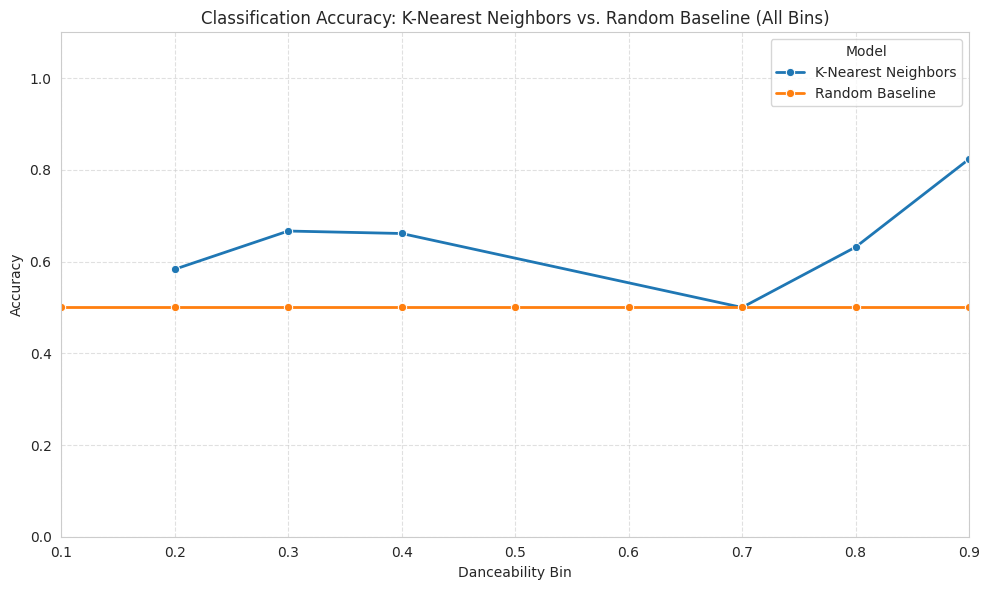

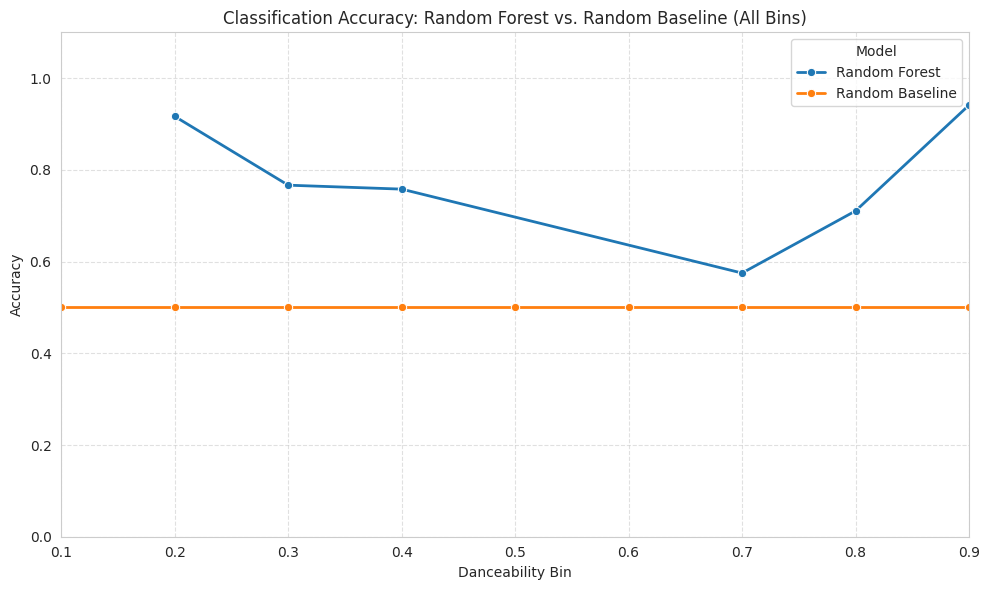

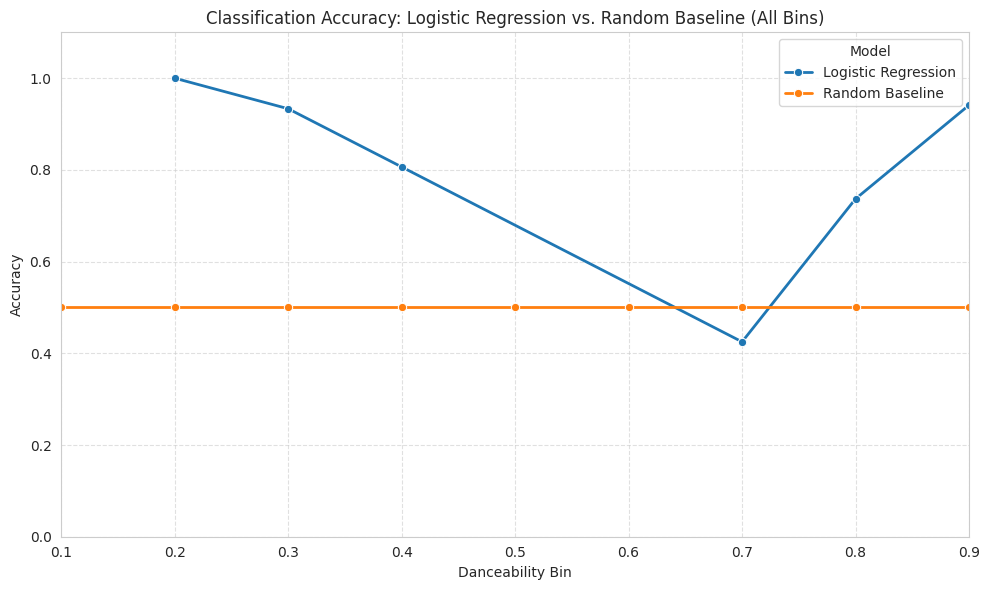

In [ ]:
models_for_accuracy = [
    'K-Nearest Neighbors',
    'Random Forest',
    'Logistic Regression'
]

x_bins = np.round(np.arange(0.1, 1.0, 0.1), 1)

for model_name in models_for_accuracy:
    plt.figure(figsize=(10, 6))

    plot_df_accuracy = melted_accuracy_df[
        (melted_accuracy_df['Model'] == model_name) |
        (melted_accuracy_df['Model'] == 'Random Baseline')
    ].copy()

    plot_df_accuracy['danceability_bin'] = plot_df_accuracy['danceability_bin'].round(1)

    full_index = pd.MultiIndex.from_product(
        [[model_name, 'Random Baseline'], x_bins],
        names=['Model', 'danceability_bin']
    )

    plot_df_accuracy = (
        plot_df_accuracy
        .set_index(['Model', 'danceability_bin'])
        .reindex(full_index)
        .reset_index()
    )

    sns.lineplot(
        data=plot_df_accuracy,
        x='danceability_bin',
        y='Accuracy',
        hue='Model',
        marker='o',
        linewidth=2
    )

    plt.title(f'Classification Accuracy: {model_name} vs. Random Baseline (All Bins)')
    plt.xlabel('Danceability Bin')
    plt.ylabel('Accuracy')

    plt.xticks(x_bins, [f'{x:.1f}' for x in x_bins])
    plt.xlim(0.1, 0.9)
    plt.ylim(0, 1.1)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')
    plt.tight_layout()

    safe_model_name = model_name.replace(" ", "_").replace("-", "")

    plt.savefig(
        f'classification_accuracy_{safe_model_name}_vs_random_baseline.pdf',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

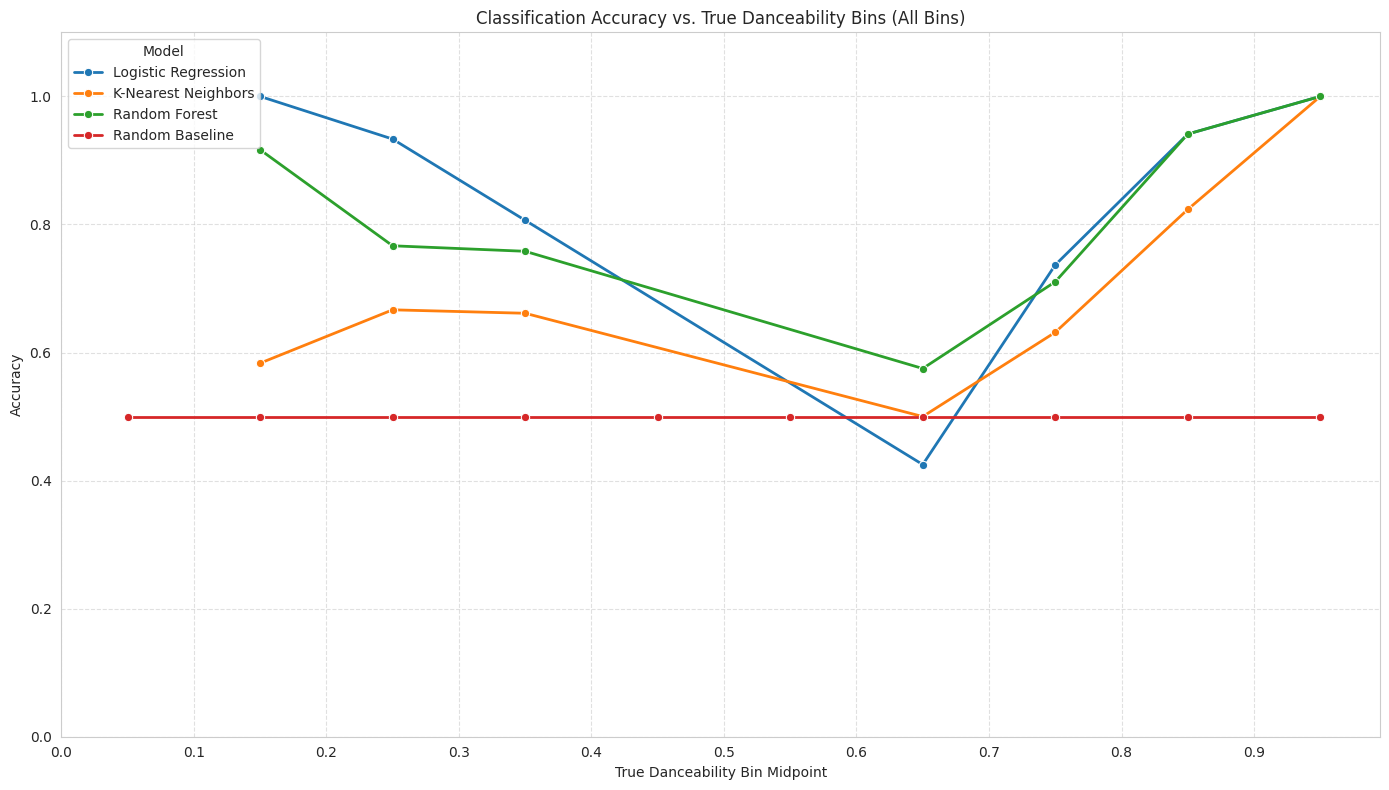

In [ ]:
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=melted_accuracy_df,
    x='danceability_bin',
    y='Accuracy',
    hue='Model',
    marker='o',
    linewidth=2
)

plt.title('Classification Accuracy vs. True Danceability Bins (All Bins)')
plt.xlabel('True Danceability Bin Midpoint')
plt.ylabel('Accuracy')
plt.xticks([x + 0.05 for x in bins[:-1]], [f'{i:.1f}' for i in bins[:-1]])
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('classification_accuracy_all_bins.pdf')
plt.show()

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.76,0.82,0.65,0.72
1,K-Nearest Neighbors,0.64,0.62,0.61,0.62
2,Random Forest,0.74,0.74,0.70,0.72
3,BERT MODEL,0.82,0.85,0.76,0.80
4,Random Baseline,0.52,0.00,0.00,0.00
5,BERT MODEL,0.82,0.85,0.76,0.80
6,Random Baseline,0.52,0.00,0.00,0.00


In [ ]:
!ls /content

additional_metrics_comparison_all_models.pdf
classification_accuracy_all_bins.pdf
classification_accuracy_K-Nearest_Neighbors_vs_random_baseline.pdf
classification_accuracy_KNearest_Neighbors_vs_random_baseline.pdf
classification_accuracy_Logistic_Regression_vs_random_baseline.pdf
classification_accuracy_Random_Forest_vs_random_baseline.pdf
classification_metrics_comparison_all_models.pdf
drive
sample_data
